In [346]:
#Carregar os pacotes e definir randon.seed para resultados reprodutíveis.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import watermark 

np.random.seed(42)

%reload_ext watermark
%watermark -a "Nathan Esser"

Author: Nathan Esser



In [347]:
#Criação de dados fictícios para realizar a análise.
num_usuarios = 500

# 1. Gerar o número de visitas de usuários ao site.
visitas = np.random.randint(1, 51, size= num_usuarios)

# 2. Gerar o tempo gasto no site (distribuição normal).
#Media de 20 min, com desvio padrão de 5, com um bônus por visita.
tempo_no_site = np.random.normal(loc = 20, scale= 5, size= num_usuarios) + (visitas * 0.5)
tempo_no_site = np.round(tempo_no_site, 2) #Ajuste para 2 casas decimais

# 3. Gerar o número de itens no carrinho (dependente das visitas e do tempo).
# Usuários que visitam mais e passam mais tempo, tendem a adicionar mais itens.
itens_no_carrinho = np.random.randint(0, 8, size = num_usuarios) + (visitas // 10)

# Influência do tempo no site no número de itens no carrinho.
itens_no_carrinho = (itens_no_carrinho +  (tempo_no_site // 15)).astype(int)

# 4. Gerar o valor da compra (correlacionando com os itens no carrinho).
# Preço médio por item de R$ 35, com alguma variação aleatória.
valor_compra = (itens_no_carrinho * 35) + np.random.normal(loc = 0, scale= 10, size = num_usuarios)

# Tratamento do valor de compra.
valor_compra [itens_no_carrinho == 0] = 0 #Mesma lógica do for i in range(num_usuarios): itenitens_no_carrinho [i] == 0: valor_compra[i] == 0
valor_compra [valor_compra < 0] = 0
valor_compra = np.round(valor_compra, 2)

dados_ecommerce = np.column_stack((visitas, tempo_no_site, itens_no_carrinho, valor_compra))

print("\nShape da nossa massa de dados:", dados_ecommerce.shape)
print("\nExemplo dos 5 primeiros usuários (linhas):")
print("\nColunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]\n")
print(dados_ecommerce[:5])


Shape da nossa massa de dados: (500, 4)

Exemplo dos 5 primeiros usuários (linhas):

Colunas: [Visitas, Tempo no Site (min), Itens no Carrinho, Valor da Compra (R$)]

[[ 39.    23.29   9.   314.54]
 [ 29.    29.38   5.   177.43]
 [ 15.    26.24   6.   207.59]
 [ 43.    35.26   8.   283.52]
 [  8.    32.16   3.    92.48]]


### Início da Análise

#### Pergunta 1

Qual é o perfil médio do nosso usuário em termos de visitas, tempo de navegação e valor de compra (ticket médio)?

--- ANÁLISE ESTATÍSTICA GERAL ---

A média de visitas é 25.86
A média de tempo no site é 32.78 min
A média de itens alocados no carrinho são 7 itens
A média do valor de compra (Ticket Médio) é R$: 252.70

A mediana do valor de compra é R$: 248.135
O desvio padrão do valor de compra é R$: 106.94
O valor máximo de compra é R$: 530.37
O valor mínimo de compra é R$: 23.42
---------------------------------------------------------


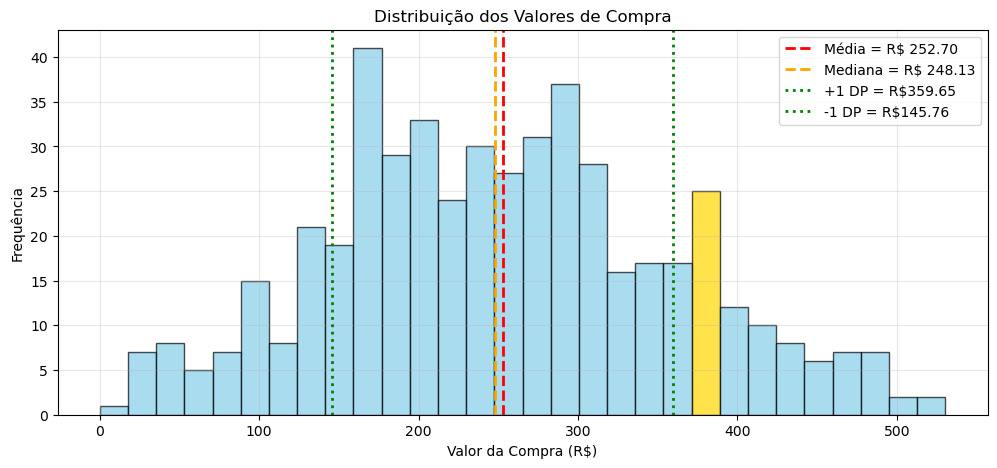

In [348]:
#Separando as colunas para análise

visitas_col = dados_ecommerce[:,0]
tempo_col = dados_ecommerce[:,1]
itens_col = dados_ecommerce[:,2]
valor_col = dados_ecommerce[:,3]

print("--- ANÁLISE ESTATÍSTICA GERAL ---")

#Média
media_visitas = np.mean(visitas_col)
media_tempo = np.mean(tempo_col)
media_itens = np.mean(itens_col)
media_valor = np.mean(valor_col)

print (f"\nA média de visitas é {media_visitas:.2f}")
print (f"A média de tempo no site é {media_tempo:.2f} min")
print (f"A média de itens alocados no carrinho são {media_itens:.0f} itens")
print (f"A média do valor de compra (Ticket Médio) é R$: {media_valor:.2f}")

# Mediana (valor central, menos sensível a outliers)
mediana_valor_compra = np.median(valor_col)
print (f"\nA mediana do valor de compra é R$: {mediana_valor_compra}")

#Desvio padrão para medir a dispersão dos dados de valor de compra
std_valor = np.std(valor_col)
print (f"O desvio padrão do valor de compra é R$: {std_valor:.2f}")

# Valores Máximos e Mínimos
max_valor = np.max(valor_col)
min_valor = np.min(valor_col[valor_col > 0]) #Mínimo apenas de quem efetuou uma compra.
print (f"O valor máximo de compra é R$: {max_valor:.2f}")
print (f"O valor mínimo de compra é R$: {min_valor:.2f}")

print("---------------------------------------------------------")

lim_inf = 355
lim_sup = 390

plt.figure(figsize = (12, 5))
counts, bin_edges, patches = plt.hist(valor_col, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
# Loop que percorre cada barra
for left, right, bar in zip(bin_edges[:-1], bin_edges[1:], patches):
    if left >= lim_inf and right <= lim_sup:
        bar.set_facecolor('gold')    # muda a cor da barra
        bar.set_edgecolor('black')

plt.axvline(media_valor, color = 'red', linestyle = '--', linewidth = 2, label = f'Média = R$ {media_valor:.2f}')
plt.axvline(mediana_valor_compra, color = 'orange', linestyle = '--', linewidth = 2, label = f'Mediana = R$ {mediana_valor_compra:.2f}')
plt.axvline(media_valor + std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'+1 DP = R${media_valor + std_valor:.2f}')
plt.axvline(media_valor - std_valor, color = 'green', linestyle = ':', linewidth = 2, label = f'-1 DP = R${media_valor - std_valor:.2f}')
plt.title('Distribuição dos Valores de Compra')
plt.xlabel('Valor da Compra (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()



<small>

**Resposta da Pergunta 1:**

- Média de acessos no site por usuário: 26 vezes/Mês
- Tempo médio de usabilidade do e-commerce: 33 minutos
- Média de itens adicionados ao carrinho: 7 itens
- Ticket médio: R$ 252,70

Comentários gerais:

Identificado alta variabilidade no valores gastos por cada cliente, com compras de R$ 23,42 até R$ 530,57.

Outro destaque fica para alta quantidade de compras entre R$ 355,00 e R$ 390,00 - Possível campanha de brindes ou frete grátis (Se ainda não aplicado) para valores de R$ 350,00 a R$ 399,00

</small>

#### Pergunta 2

Quais são as características e comportamentos distintos dos nossos clientes de "Alto Valor"? Eles visitam mais o site? Passam mais tempo navegando?

In [349]:
#Filtro para localizar os clientes que gastaram mais que R$ 250,00
clientes_alto_valor = dados_ecommerce [dados_ecommerce [:, 3] > 250]

print("\n--- ANÁLISE: CLIENTES DE ALTO VALOR (Compras > R$ 250) ---\n")
print(f"Volume de clientes classificados como 'Alto Valor' é {clientes_alto_valor.shape[0]}" )

#Estatísticas desses clientes
media_visitas_alto_valor = np.mean(clientes_alto_valor[:,0])
media_tempo_alto_valor = np.mean(clientes_alto_valor[:,1])

#Comparativo percentual
per_tempo_alvalor_x_geral = ((media_tempo_alto_valor - media_tempo) / media_tempo)*100
per_visitas_alvalor_x_geral = ((media_visitas_alto_valor - media_visitas) / media_visitas)*100

print(f"A média de visitas desses clientes: {media_visitas_alto_valor:.0f} visitas, {per_visitas_alvalor_x_geral:.2f}% maior que a média geral por usário." )
print(f"A média de tempo gasto no site desses clientes: {media_tempo_alto_valor:.2f} min, {per_tempo_alvalor_x_geral:.2f}% maior que a média geral por usário." )




--- ANÁLISE: CLIENTES DE ALTO VALOR (Compras > R$ 250) ---

Volume de clientes classificados como 'Alto Valor' é 245
A média de visitas desses clientes: 33 visitas, 28.70% maior que a média geral por usário.
A média de tempo gasto no site desses clientes: 37.11 min, 13.21% maior que a média geral por usário.


<small>

**Resposta da Pergunta 2:**

- Clientes identificados como "Alto Valor" : 245
- Média de visitas no site do e-commerce : 33 (+29% que a média geral)
- Tempo médio de usabilidade do e-commerce por clientes de "Alto Valor" : 37 minutos (+13% que média geral)

Comentários gerais:

Clientes classificados como Alto Valor compreendem próximo de 50% do total de usuários.

Demonstrando maior engajamento na plataforma, com maior número de visitas e mais tempo de usabilidade que a média geral.

</small>


#### Pergunta 3

Qual é o comportamento dos usuários que visitam o site, mas não realizam nenhuma compra? Onde está a oportunidade de conversão com este grupo?

In [350]:
#Filtro para localizar os visitante sem compras
visitantes_sem_compras = dados_ecommerce[dados_ecommerce[:,3] == 0]

print("\n--- ANÁLISE: CLIENTES SEM COMPRAS ---\n")
print(f"Volume de cliente(s) sem compras é: {visitantes_sem_compras.shape[0]}" )

#Estatísticas desses clientes
media_visitas_sem_compras = np.mean(visitantes_sem_compras[:,0])
media_tempo_sem_compras = np.mean(visitantes_sem_compras[:,1])

print(f"A média de visitas desses clientes: {media_visitas_sem_compras:.0f} visitas")
print(f"A média de tempo gasto no site desses clientes: {media_tempo_sem_compras:.2f} min")


--- ANÁLISE: CLIENTES SEM COMPRAS ---

Volume de cliente(s) sem compras é: 1
A média de visitas desses clientes: 7 visitas
A média de tempo gasto no site desses clientes: 14.71 min


<small>

**Resposta da Pergunta 3:**

- Clientes que visitaram o site mas não realizaram nenhuma compra: 1 
- Média de visitas no site do e-commerce : 7
- Tempo médio de usabilidade do e-commerce por esses visitantes : 14 min

Comentários gerais:

Os dados apresentam que apenas 1 cliente acessou o site e não realizou nenhuma compra, com volume médio de 7 visitas e uma média de 14 minutos de usabilidade do site. 

Apesar de ser um volume baixo, vale identificar ações de remarkting, e entender o momento do abandono no site (Checkout, páginas de produtos...)

</small>


### Pergunta 4

Existe uma correlação estatisticamente relevante entre o tempo gasto no site, o número de itens no carrinho e o valor final da compra?

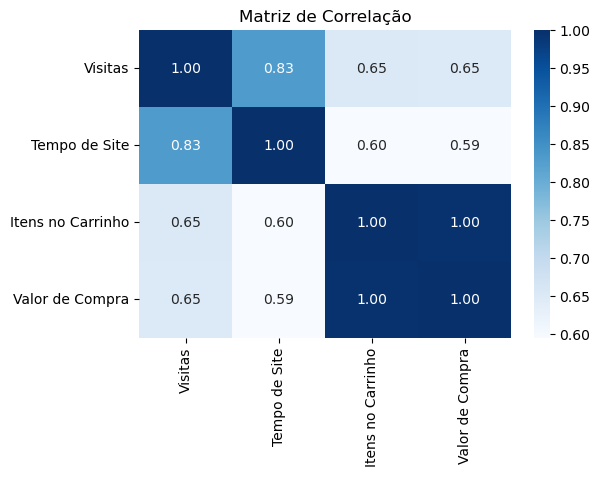

In [351]:
#Método: Calcular a Matriz de correlação e plotar os dados em gráfico para análise final.
#Cálculo da Matriz de Correlação
matriz_correlacao = np.corrcoef(dados_ecommerce, rowvar= False) #rowvar = False indica que as colunas são as variáveis

#Definir as variáveis dessa matriz
nomes_variaveis = ["Visitas", "Tempo de Site", "Itens no Carrinho", "Valor de Compra"]

#Conversão para Dataframe para exibir os rótulos
df_correlacao = pd.DataFrame(matriz_correlacao,
                             index= nomes_variaveis,
                             columns= nomes_variaveis)

#Mapa de Calor
plt.figure(figsize= (6,4))
sns.heatmap(df_correlacao, annot = True, cmap = "Blues", fmt = '.2f' )
plt.title("Matriz de Correlação")
plt.show()



<small>

**Resposta da Pergunta 4:**

A matriz está organizada na ordem [Visitas, Tempo, Itens, Valor]. Os valores variam entre –1 e +1, onde:

- +1 indica correlação positiva perfeita
- 0 indica ausência de correlação
- –1 indica correlação negativa perfeita

Análise de Relações

- Tempo x Valor de Compra: 0,59 → Correlação positiva moderada.
- Itens x Valor de Compra: 1,00 → Correlação positiva perfeita (A forma como o dataset foi criado contribui para essa correlação)
- Tempo x Itens: 0,60 → Correlaçaõ positiva moderada.
- Itens x Visitas: 0,65 → Correlaçaõ positiva moderada.

Comentários gerais:

Sim, há uma correlação relevante. Os dados mostram que quanto maior o tempo de uso no site, mais itens o usuário adiciona no carrinho e consequentemente, maior o valor de compra. Além
do que usuários que visitam mais o site, tendem a ter mais itens adicionados ao carrinho (Comprovado pelos usuários de "Alto Valor")

</small>
